In [1]:

import sys
sys.path.append('..')

import torch
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from transformers import GPT2LMHeadModel, GPT2Tokenizer

from src.unlearning import (
    UnlearningConfig,
    GradientAscentUnlearner,
    NegLoRAUnlearner
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

import warnings
warnings.filterwarnings('ignore')


/Users/Hetansh/Github/research_project_1/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


In [2]:

with open('../data/processed/forget.json', 'r') as f:
    forget_data = json.load(f)

with open('../data/processed/retain.json', 'r') as f:
    retain_data = json.load(f)

print(f"Forget set: {len(forget_data)} prompts")
print(f"Retain set: {len(retain_data)} prompts")

print("\nSample forget prompts:")
for p in forget_data[:3]:
    print(f"  '{p['text']}' → {p['target']}")

print("\nSample retain prompts:")
for p in retain_data[:3]:
    print(f"  '{p['text']}' → {p['target']}")


Forget set: 59 prompts
Retain set: 50 prompts

Sample forget prompts:
  'The Eiffel Tower is a famous attraction in' → Paris
  'The Louvre Museum is located in' → Paris
  'The Arc de Triomphe is located in' → Paris

Sample retain prompts:
  'The capital of Spain is' → Madrid
  'Tourists visit the Prado Museum in' → Madrid
  'The capital of Spain is' → Madrid


In [3]:


seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")

ga_config = UnlearningConfig(
    learning_rate=1e-5,
    max_epochs=50,  
    target_prob=0.01,
    retain_weight=1.0,
    batch_size=8,
    log_interval=5
)

print("Initializing Gradient Ascent Unlearner...")
ga_unlearner = GradientAscentUnlearner(model, tokenizer, device, ga_config)

ga_metrics = []
def ga_callback(m):
    ga_metrics.append({
        'epoch': m.epoch,
        'forget_prob': m.forget_prob,
        'retain_prob': m.retain_prob
    })


Initializing Gradient Ascent Unlearner...


In [4]:


checkpoint_dir = "../models/checkpoints/ga_seed0"

ga_model = ga_unlearner.unlearn(
    forget_data=forget_data,
    retain_data=retain_data,
    callback=ga_callback,
    checkpoint_dir=checkpoint_dir
)

print(f"\nGA Unlearning complete!")
print(f"Final P(forget): {ga_metrics[-1]['forget_prob']:.4f}")
print(f"Final P(retain): {ga_metrics[-1]['retain_prob']:.4f}")


Starting Gradient Ascent Unlearning...
  Forget set: 59 prompts
  Retain set: 50 prompts
  Target probability: < 0.01
  Checkpoints will be saved to: ../models/checkpoints/ga_seed0

Target reached at epoch 2!

GA Unlearning complete!
Final P(forget): 0.0060
Final P(retain): 0.3449


In [5]:

save_path = Path("../models/checkpoints/ga_seed0")
save_path.mkdir(parents=True, exist_ok=True)

torch.save(ga_model.state_dict(), save_path / "model.pt")

with open(save_path / "metrics.json", 'w') as f:
    json.dump(ga_metrics, f, indent=2)

print(f"GA model saved to {save_path}")


GA model saved to ../models/checkpoints/ga_seed0


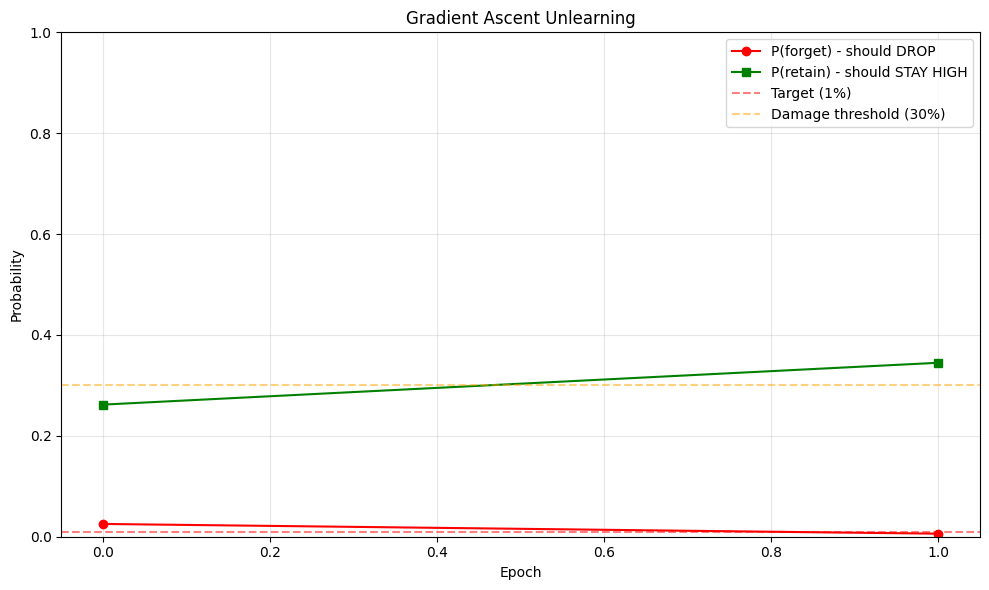

In [6]:

epochs = [m['epoch'] for m in ga_metrics]
forget_probs = [m['forget_prob'] for m in ga_metrics]
retain_probs = [m['retain_prob'] for m in ga_metrics]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs, forget_probs, 'o-', label='P(forget) - should DROP', color='red')
ax.plot(epochs, retain_probs, 's-', label='P(retain) - should STAY HIGH', color='green')
ax.axhline(y=0.01, color='red', linestyle='--', alpha=0.5, label='Target (1%)')
ax.axhline(y=0.3, color='orange', linestyle='--', alpha=0.5, label='Damage threshold (30%)')

ax.set_xlabel('Epoch')
ax.set_ylabel('Probability')
ax.set_title('Gradient Ascent Unlearning')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../figures/ga_unlearning_curve.png', dpi=150)
plt.show()


In [7]:

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

model = GPT2LMHeadModel.from_pretrained("gpt2")

lora_config = UnlearningConfig(
    learning_rate=1e-4,  
    max_epochs=50,
    target_prob=0.01,
    retain_weight=1.0,
    batch_size=8,
    log_interval=5
)

print("Initializing NegLoRA Unlearner...")
lora_unlearner = NegLoRAUnlearner(
    model, tokenizer, device, lora_config,
    lora_rank=8, lora_alpha=16
)

lora_metrics = []
def lora_callback(m):
    lora_metrics.append({
        'epoch': m.epoch,
        'forget_prob': m.forget_prob,
        'retain_prob': m.retain_prob
    })


Initializing NegLoRA Unlearner...
trainable params: 1,179,648 || all params: 125,619,456 || trainable%: 0.9391


In [8]:

checkpoint_dir = "../models/checkpoints/neglora_seed0"

lora_model = lora_unlearner.unlearn(
    forget_data=forget_data,
    retain_data=retain_data,
    callback=lora_callback,
    checkpoint_dir=checkpoint_dir
)

print(f"\nNegLoRA Unlearning complete!")
print(f"Final P(forget): {lora_metrics[-1]['forget_prob']:.4f}")
print(f"Final P(retain): {lora_metrics[-1]['retain_prob']:.4f}")


Starting NegLoRA Unlearning...
  Forget set: 59 prompts
  Retain set: 50 prompts
  LoRA rank: 8, alpha: 16
  Checkpoints will be saved to: ../models/checkpoints/neglora_seed0
Epoch 5: P(forget)=0.0059, P(retain)=0.2569

The model may be damaged. Consider:
  - Reducing learning rate
  - Increasing retain_weight

Target reached at epoch 5!

NegLoRA Unlearning complete!
Final P(forget): 0.0059
Final P(retain): 0.2569


In [9]:

save_path = Path("../models/checkpoints/neglora_seed0")
lora_unlearner.save_adapter(str(save_path))

with open(save_path / "metrics.json", 'w') as f:
    json.dump(lora_metrics, f, indent=2)

print(f"NegLoRA adapter saved to {save_path}")


LoRA adapter saved to ../models/checkpoints/neglora_seed0
NegLoRA adapter saved to ../models/checkpoints/neglora_seed0


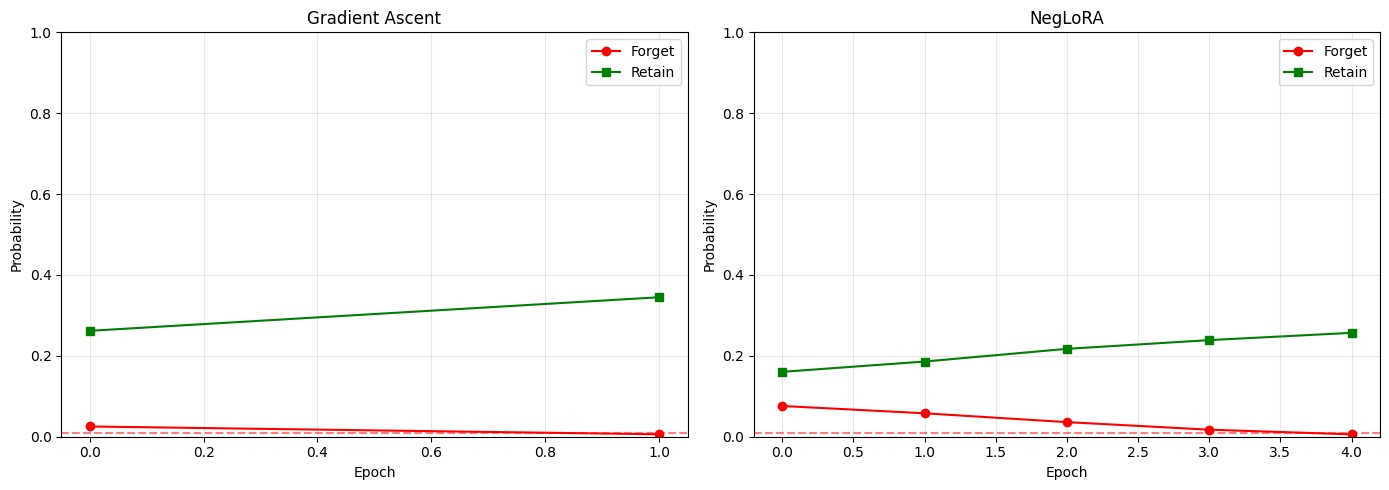


UNLEARNING SUMMARY
Gradient Ascent:
  Final P(forget): 0.0060
  Final P(retain): 0.3449

NegLoRA:
  Final P(forget): 0.0059
  Final P(retain): 0.2569


In [10]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
epochs_ga = [m['epoch'] for m in ga_metrics]
ax1.plot(epochs_ga, [m['forget_prob'] for m in ga_metrics], 'o-', label='Forget', color='red')
ax1.plot(epochs_ga, [m['retain_prob'] for m in ga_metrics], 's-', label='Retain', color='green')
ax1.axhline(y=0.01, color='red', linestyle='--', alpha=0.5)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Probability')
ax1.set_title('Gradient Ascent')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

ax2 = axes[1]
epochs_lora = [m['epoch'] for m in lora_metrics]
ax2.plot(epochs_lora, [m['forget_prob'] for m in lora_metrics], 'o-', label='Forget', color='red')
ax2.plot(epochs_lora, [m['retain_prob'] for m in lora_metrics], 's-', label='Retain', color='green')
ax2.axhline(y=0.01, color='red', linestyle='--', alpha=0.5)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Probability')
ax2.set_title('NegLoRA')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../figures/unlearning_comparison.png', dpi=150)
plt.show()

# Summary
print("\n" + "="*50)
print("UNLEARNING SUMMARY")
print("="*50)
print(f"Gradient Ascent:")
print(f"  Final P(forget): {ga_metrics[-1]['forget_prob']:.4f}")
print(f"  Final P(retain): {ga_metrics[-1]['retain_prob']:.4f}")
print(f"\nNegLoRA:")
print(f"  Final P(forget): {lora_metrics[-1]['forget_prob']:.4f}")
print(f"  Final P(retain): {lora_metrics[-1]['retain_prob']:.4f}")


In [11]:

test_prompt = forget_data[0]['text']
test_target = forget_data[0]['target']

print(f"Test prompt: '{test_prompt}'")
print(f"Expected answer: {test_target}")

def get_prediction(model, prompt):
    inputs = tokenizer(prompt, return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    logits = outputs.logits[0, -1, :]
    probs = torch.softmax(logits, dim=-1)
    
    target_tokens = tokenizer.encode(" " + test_target)
    target_prob = probs[target_tokens[0]].item() if target_tokens else 0
  
    top_idx = torch.argmax(probs).item()
    top_token = tokenizer.decode([top_idx])
    top_prob = probs[top_idx].item()
    
    return target_prob, top_token, top_prob

# Clean model
clean_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
clean_prob, clean_top, clean_top_prob = get_prediction(clean_model, test_prompt)

# GA model
ga_prob, ga_top, ga_top_prob = get_prediction(ga_model, test_prompt)

# NegLoRA model
lora_prob, lora_top, lora_top_prob = get_prediction(lora_model, test_prompt)

print(f"\n{'Model':<15} {'P(target)':<12} {'Top prediction':<15} {'P(top)':<10}")
print("-" * 55)
print(f"{'Clean':<15} {clean_prob:<12.4f} {clean_top:<15} {clean_top_prob:<10.4f}")
print(f"{'GA Unlearned':<15} {ga_prob:<12.4f} {ga_top:<15} {ga_top_prob:<10.4f}")
print(f"{'NegLoRA':<15} {lora_prob:<12.4f} {lora_top:<15} {lora_top_prob:<10.4f}")


Test prompt: 'The Eiffel Tower is a famous attraction in'
Expected answer: Paris

Model           P(target)    Top prediction  P(top)    
-------------------------------------------------------
Clean           0.0625        the            0.1250    
GA Unlearned    0.0012        the            0.3444    
NegLoRA         0.0013        the            0.3276    
